* **`Scenario`**: identificativo dello scenario considerato, cioè della specifica configurazione di rete e di placement analizzata.

* **`App_ms`**: identificativo completo dell’applicazione o catena di microservizi considerata.

* **`App_group`**: versione aggregata di `App_ms` che ignora il prefisso numerico iniziale e mantiene solo la struttura dell’applicazione.

* **`Node_Weight_Sum`**: somma dei pesi `c_i` dei nodi su cui sono stati deployati i servizi dell’applicazione.  
  Se `x_ui` è la variabile binaria di assegnazione che vale `1` quando il servizio `u` è deployato sul nodo `i` e `0` altrimenti, allora questa metrica rappresenta il contributo del placement alla funzione obiettivo nella forma:

  $$
  \sum_u \sum_i x_{ui} c_i
  $$

* **`Service_Weighted_Node_Weight_Sum`**: somma dei pesi dei nodi ulteriormente pesata con la domanda di CPU dei servizi.  
  Se `q_u` è la domanda di CPU del servizio `u`, allora questa metrica corrisponde al termine:

  $$
  \sum_u \sum_i x_{ui} q_u c_i
  $$

  e misura quindi il costo del placement tenendo conto anche della “dimensione” dei servizi.

* **`Num_Services`**: numero totale di servizi dell’applicazione che risultano effettivamente assegnati a un nodo.

* **`Used_Nodes_Count`**: numero di nodi distinti utilizzati per ospitare i servizi dell’applicazione.

* **`Zero_Cost_Used_Nodes`**: numero di nodi utilizzati che hanno peso `c_i = 0`, utile per verificare se il costo del placement è influenzato dalla presenza di nodi a costo nullo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils.scenario_utils import build_objective_cost_dataset, build_resource_stress_dataset

df = pd.read_pickle("processed_data/dataset_worst_case_scenarios.pkl")
df.head()

,Distribution,Scenario,App_ms,App_group,Run,User,Application,Total Delay,Delay SLAs,SLA_Violation,SLA_Margin,SLA_Margin_Perc,Violation_Amount,Processing Delay,Propagation Delay
0,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_392,1,1,58,63.924,False,-5.924,-9.267,0.0,33,25
1,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_619,2,2,49,63.924,False,-14.924,-23.346,0.0,23,26
2,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_976,2,2,53,63.924,False,-10.924,-17.089,0.0,27,26
3,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_338,1,1,56,63.924,False,-7.924,-12.396,0.0,31,25
4,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_235,1,1,55,63.924,False,-8.924,-13.960,0.0,30,25


In [2]:
objective_df = build_objective_cost_dataset()
objective_df

,Scenario,App_ms,App_group,Node_Weight_Sum,Service_Weighted_Node_Weight_Sum,Num_Services,Used_Nodes_Count,Zero_Cost_Used_Nodes
0,1_26_solution_v0,1SMM,SMM,0.318333,7.550000,6,4,1
1,1_26_solution_v0,1SMS,SMS,0.331667,7.643333,7,5,1
2,1_26_solution_v0,1SSM,SSM,0.168333,2.150000,7,5,2
3,1_26_solution_v0,1SSS,SSS,0.190000,1.851667,8,5,2
4,1_26_solution_v10,1MMM,MMM,0.290000,5.950000,5,3,1
5,1_26_solution_v10,1MMS,MMS,0.290000,5.950000,6,4,2
6,1_26_solution_v10,1MSM,MSM,0.116667,0.683333,6,4,2
7,1_26_solution_v10,1MSS,MSS,0.123333,0.696667,7,4,2
8,1_26_solution_v10,1SMM,SMM,0.290000,5.766667,6,4,2
9,1_26_solution_v10,1SMS,SMS,0.296667,5.866667,7,4,1


In [3]:
scatter_df = df.merge(
    objective_df,
    on=["Scenario", "App_ms", "App_group"],
    how="left"
)

scatter_df.head()

,Distribution,Scenario,App_ms,App_group,Run,User,Application,Total Delay,Delay SLAs,SLA_Violation,SLA_Margin,SLA_Margin_Perc,Violation_Amount,Processing Delay,Propagation Delay,Node_Weight_Sum,Service_Weighted_Node_Weight_Sum,Num_Services,Used_Nodes_Count,Zero_Cost_Used_Nodes
0,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_392,1,1,58,63.924,False,-5.924,-9.267,0.0,33,25,0.773889,12.444444,10,6,1
1,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_619,2,2,49,63.924,False,-14.924,-23.346,0.0,23,26,0.773889,12.444444,10,6,1
2,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_976,2,2,53,63.924,False,-10.924,-17.089,0.0,27,26,0.773889,12.444444,10,6,1
3,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_338,1,1,56,63.924,False,-7.924,-12.396,0.0,31,25,0.773889,12.444444,10,6,1
4,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_235,1,1,55,63.924,False,-8.924,-13.960,0.0,30,25,0.773889,12.444444,10,6,1


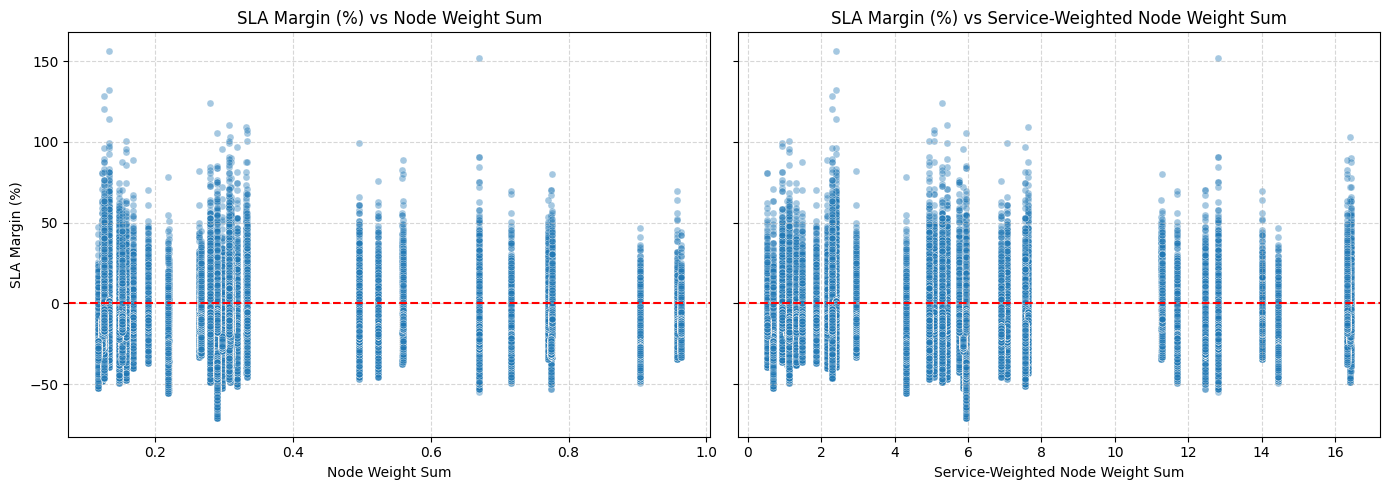

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.scatterplot(
    data=scatter_df,
    x="Node_Weight_Sum",
    y="SLA_Margin_Perc",
    alpha=0.4,
    s=25,
    ax=axes[0],
    legend=False
)

axes[0].axhline(0, linestyle="--", color="red")
axes[0].set_title("SLA Margin (%) vs Node Weight Sum")
axes[0].set_xlabel("Node Weight Sum")
axes[0].set_ylabel("SLA Margin (%)")
axes[0].grid(True, linestyle="--", alpha=0.5)

sns.scatterplot(
    data=scatter_df,
    x="Service_Weighted_Node_Weight_Sum",
    y="SLA_Margin_Perc",
    alpha=0.4,
    s=25,
    ax=axes[1],
    legend=False
)

axes[1].axhline(0, linestyle="--", color="red")
axes[1].set_title("SLA Margin (%) vs Service-Weighted Node Weight Sum")
axes[1].set_xlabel("Service-Weighted Node Weight Sum")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [5]:
agg_df = (
    scatter_df.groupby(["Distribution", "App_group"])
    .agg(
        Mean_SLA_Margin_Perc=("SLA_Margin_Perc", "mean"),
        Median_SLA_Margin_Perc=("SLA_Margin_Perc", "median"),
        Violation_Rate=("SLA_Violation", "mean"),
        Mean_Node_Weight_Sum=("Node_Weight_Sum", "mean"),
        Mean_Service_Weighted_Node_Weight_Sum=("Service_Weighted_Node_Weight_Sum", "mean"),
        Mean_Zero_Cost_Used_Nodes=("Zero_Cost_Used_Nodes", "mean"),
    )
    .reset_index()
)

agg_df["Violation_Rate"] = agg_df["Violation_Rate"] * 100
agg_df.head()

,Distribution,App_group,Mean_SLA_Margin_Perc,Median_SLA_Margin_Perc,Violation_Rate,Mean_Node_Weight_Sum,Mean_Service_Weighted_Node_Weight_Sum,Mean_Zero_Cost_Used_Nodes
0,deterministic,MMM,-19.83200,-16.4990,0.0,0.353333,6.312500,0.75
1,deterministic,MMS,-11.12375,-8.0730,0.0,0.360000,6.221667,1.00
2,deterministic,MSM,-26.70900,-26.7090,0.0,0.510000,7.558333,1.50
3,deterministic,MSS,-23.23750,-23.2375,0.0,0.513333,7.565000,1.50
4,deterministic,SMM,-12.65070,-11.2355,0.0,0.372056,8.338333,1.00


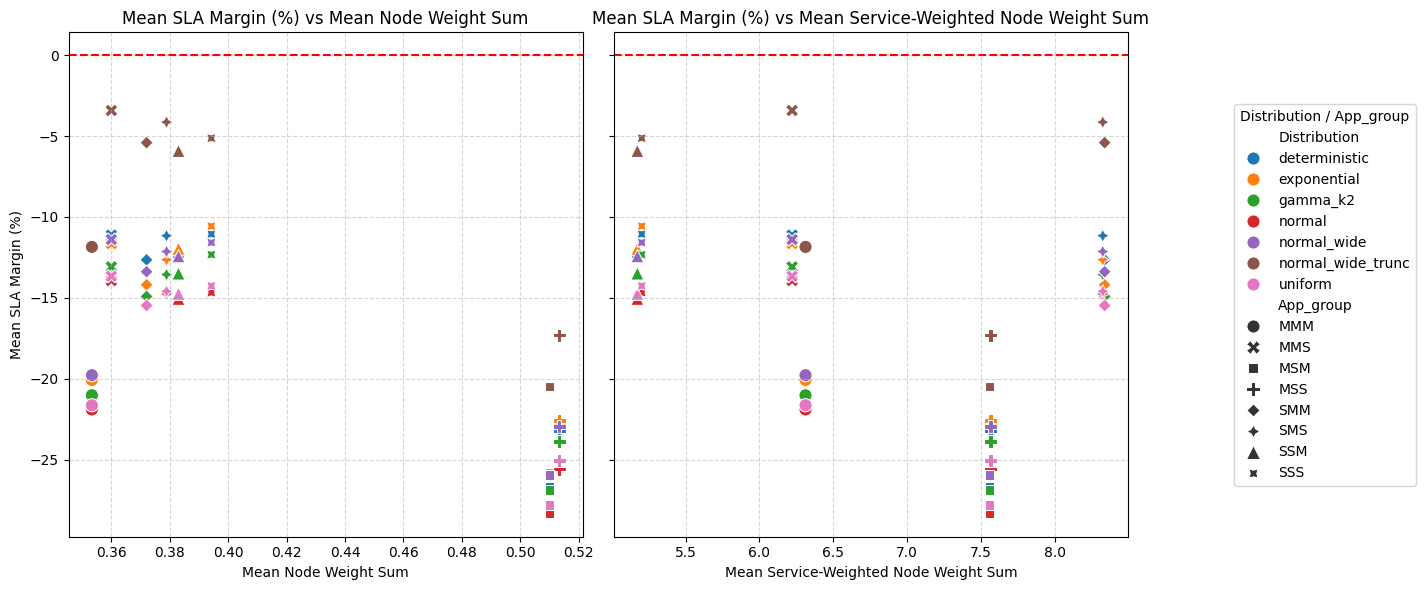

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

common_kwargs = dict(
    data=agg_df,
    y="Mean_SLA_Margin_Perc",
    hue="Distribution",
    style="App_group",
    s=90
)

sns.scatterplot(
    x="Mean_Node_Weight_Sum",
    ax=axes[0],
    legend=True,
    **common_kwargs
)

axes[0].axhline(0, linestyle="--", color="red")
axes[0].set_title("Mean SLA Margin (%) vs Mean Node Weight Sum")
axes[0].set_xlabel("Mean Node Weight Sum")
axes[0].set_ylabel("Mean SLA Margin (%)")
axes[0].grid(True, linestyle="--", alpha=0.5)

sns.scatterplot(
    x="Mean_Service_Weighted_Node_Weight_Sum",
    ax=axes[1],
    legend=False,
    **common_kwargs
)

axes[1].axhline(0, linestyle="--", color="red")
axes[1].set_title("Mean SLA Margin (%) vs Mean Service-Weighted Node Weight Sum")
axes[1].set_xlabel("Mean Service-Weighted Node Weight Sum")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle="--", alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5),
    frameon=True,
    title="Distribution / App_group"
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

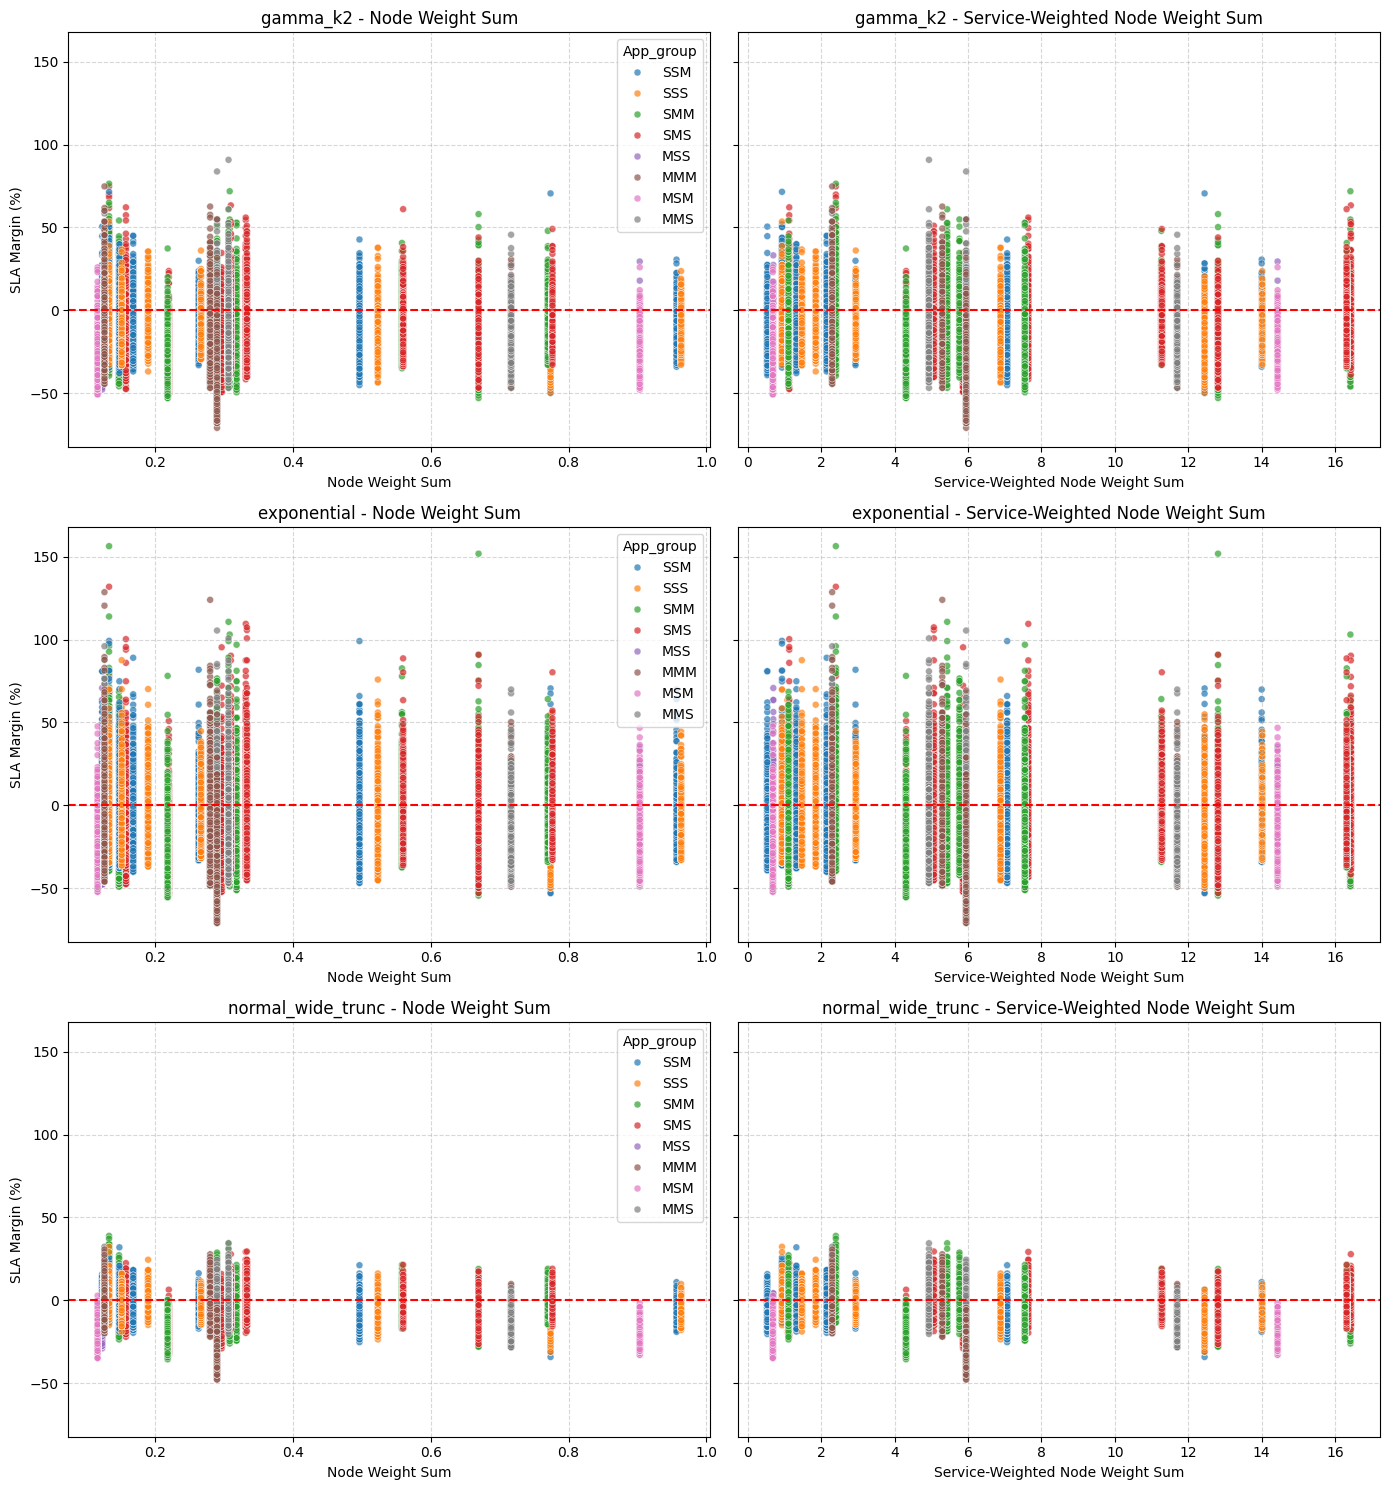

In [7]:
dists = ["gamma_k2", "exponential", "normal_wide_trunc"]

fig, axes = plt.subplots(
    nrows=len(dists),
    ncols=2,
    figsize=(14, 5 * len(dists)),
    sharey=True
)

if len(dists) == 1:
    axes = np.array([axes])

for i, dist_to_plot in enumerate(dists):
    plot_df = scatter_df[scatter_df["Distribution"] == dist_to_plot].copy()

    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    sns.scatterplot(
        data=plot_df,
        x="Node_Weight_Sum",
        y="SLA_Margin_Perc",
        hue="App_group",
        alpha=0.7,
        s=25,
        ax=ax_left,
    )

    sns.scatterplot(
        data=plot_df,
        x="Service_Weighted_Node_Weight_Sum",
        y="SLA_Margin_Perc",
        hue="App_group",
        alpha=0.7,
        s=25,
        ax=ax_right,
        legend=False
    )

    ax_left.axhline(0, linestyle="--", color="red")
    ax_left.set_title(f"{dist_to_plot} - Node Weight Sum")
    ax_left.set_xlabel("Node Weight Sum")
    ax_left.set_ylabel("SLA Margin (%)")
    ax_left.grid(True, linestyle="--", alpha=0.5)

    ax_right.axhline(0, linestyle="--", color="red")
    ax_right.set_title(f"{dist_to_plot} - Service-Weighted Node Weight Sum")
    ax_right.set_xlabel("Service-Weighted Node Weight Sum")
    ax_right.set_ylabel("")
    ax_right.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

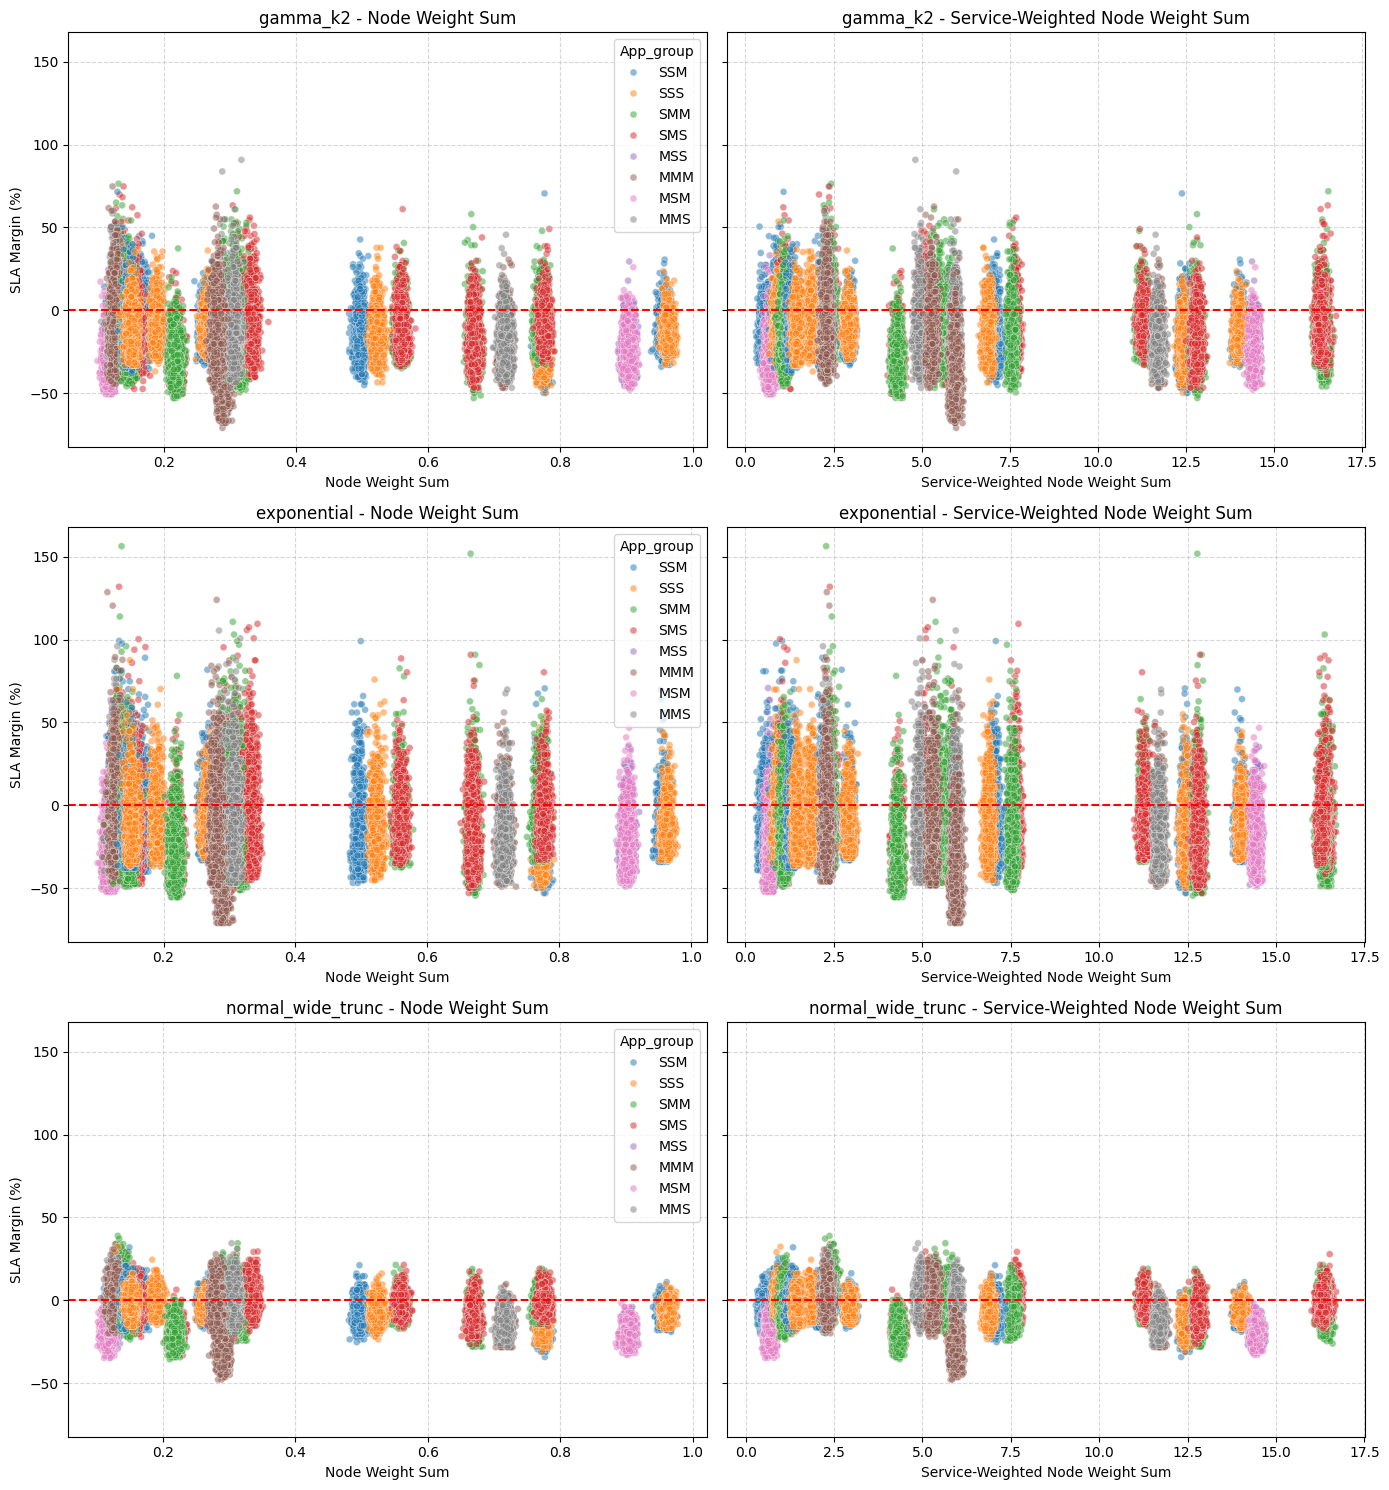

In [8]:
rng = np.random.default_rng(42)

fig, axes = plt.subplots(
    nrows=len(dists),
    ncols=2,
    figsize=(14, 5 * len(dists)),
    sharey=True
)

if len(dists) == 1:
    axes = np.array([axes])

jitter_node = 0.005
jitter_weighted = 0.08

for i, dist_to_plot in enumerate(dists):
    plot_df = scatter_df[scatter_df["Distribution"] == dist_to_plot].copy()

    plot_df["Node_Weight_Sum_Jitter"] = (
        plot_df["Node_Weight_Sum"] + rng.normal(0, jitter_node, size=len(plot_df))
    )
    plot_df["Service_Weighted_Node_Weight_Sum_Jitter"] = (
        plot_df["Service_Weighted_Node_Weight_Sum"] + rng.normal(0, jitter_weighted, size=len(plot_df))
    )

    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    sns.scatterplot(
        data=plot_df,
        x="Node_Weight_Sum_Jitter",
        y="SLA_Margin_Perc",
        hue="App_group",
        alpha=0.5,
        s=25,
        ax=ax_left,
    )

    sns.scatterplot(
        data=plot_df,
        x="Service_Weighted_Node_Weight_Sum_Jitter",
        y="SLA_Margin_Perc",
        hue="App_group",
        alpha=0.5,
        s=25,
        ax=ax_right,
        legend=False
    )

    ax_left.axhline(0, linestyle="--", color="red")
    ax_left.set_title(f"{dist_to_plot} - Node Weight Sum")
    ax_left.set_xlabel("Node Weight Sum")
    ax_left.set_ylabel("SLA Margin (%)")
    ax_left.grid(True, linestyle="--", alpha=0.5)

    ax_right.axhline(0, linestyle="--", color="red")
    ax_right.set_title(f"{dist_to_plot} - Service-Weighted Node Weight Sum")
    ax_right.set_xlabel("Service-Weighted Node Weight Sum")
    ax_right.set_ylabel("")
    ax_right.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

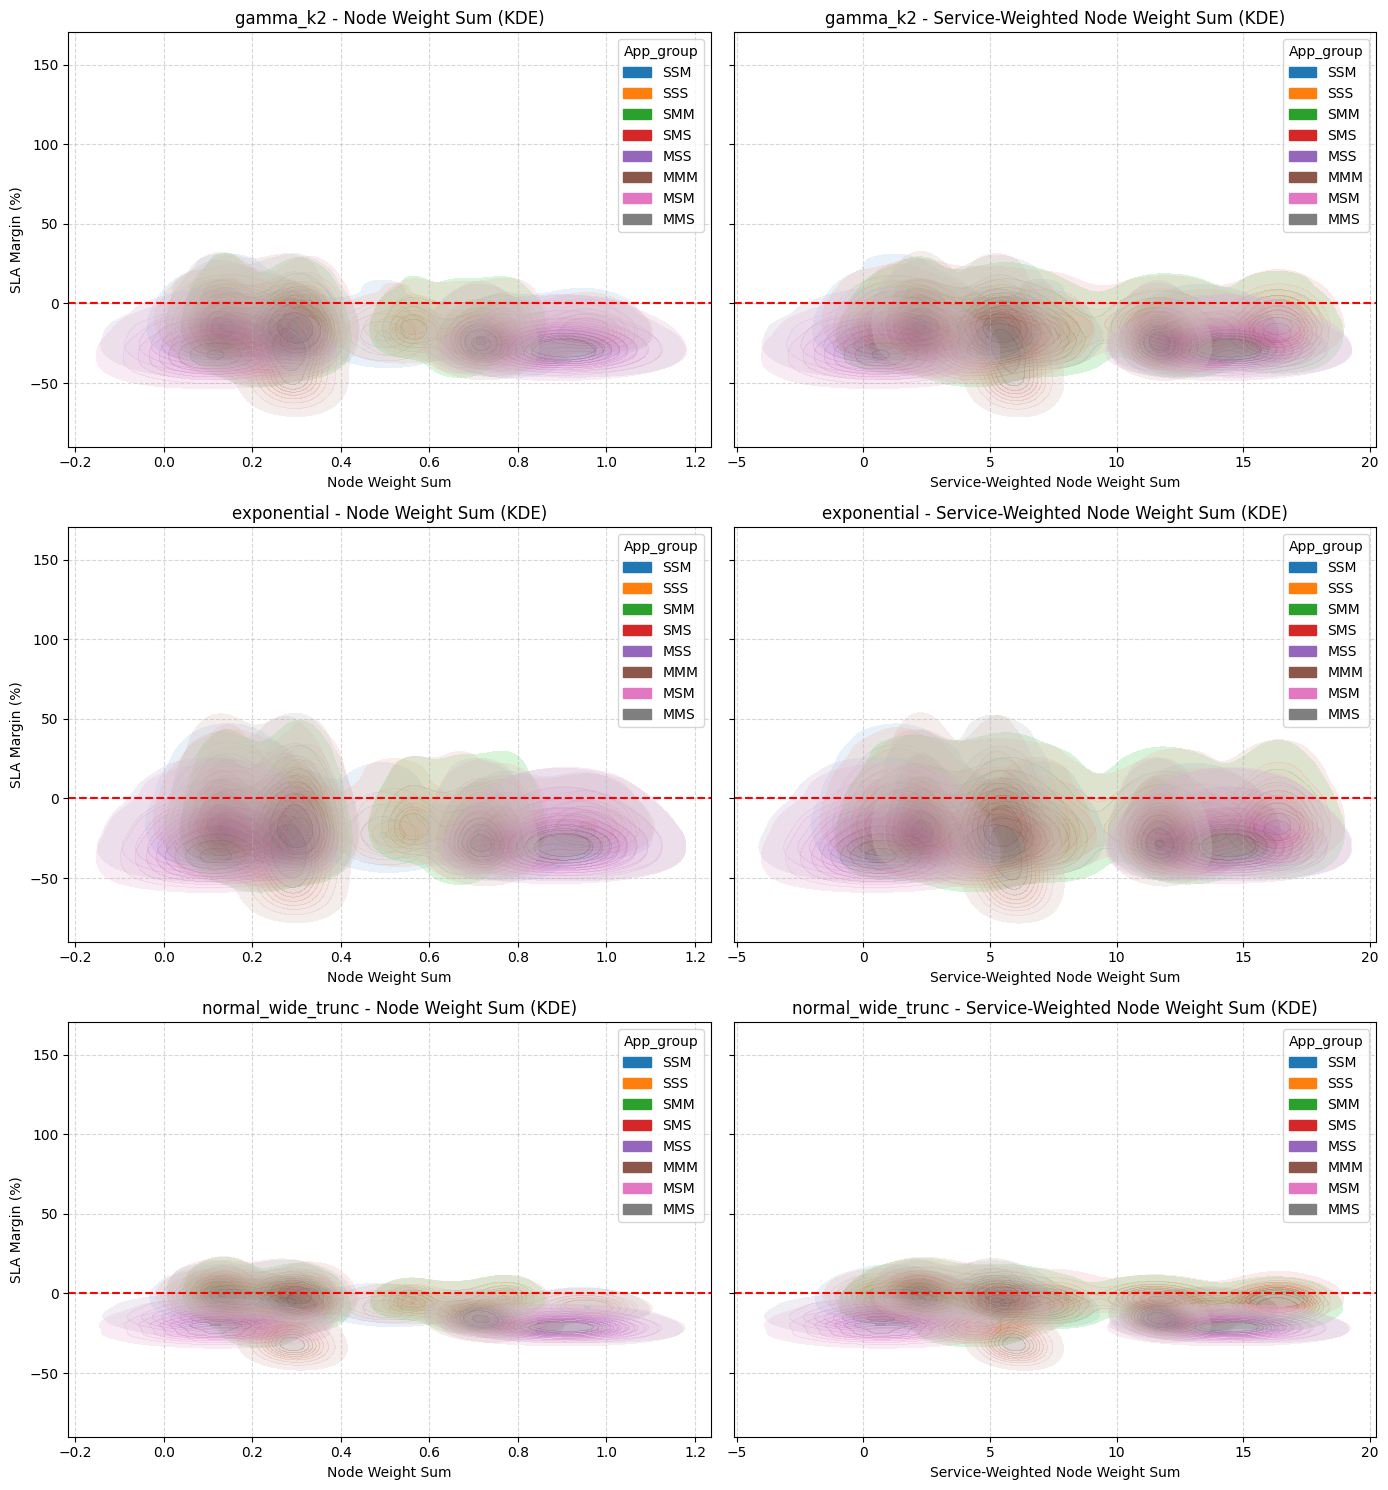

In [9]:
fig, axes = plt.subplots(
    nrows=len(dists),
    ncols=2,
    figsize=(14, 5 * len(dists)),
    sharey=True
)

if len(dists) == 1:
    axes = [axes]

for i, dist_to_plot in enumerate(dists):
    plot_df = scatter_df[scatter_df["Distribution"] == dist_to_plot].copy()

    ax_left = axes[i][0]
    ax_right = axes[i][1]

    sns.kdeplot(
        data=plot_df,
        x="Node_Weight_Sum",
        y="SLA_Margin_Perc",
        hue="App_group",
        fill=True,
        alpha=0.25,
        common_norm=False,
        ax=ax_left
    )

    sns.kdeplot(
        data=plot_df,
        x="Service_Weighted_Node_Weight_Sum",
        y="SLA_Margin_Perc",
        hue="App_group",
        fill=True,
        alpha=0.25,
        common_norm=False,
        ax=ax_right
    )

    ax_left.axhline(0, linestyle="--", color="red")
    ax_left.set_title(f"{dist_to_plot} - Node Weight Sum (KDE)")
    ax_left.set_xlabel("Node Weight Sum")
    ax_left.set_ylabel("SLA Margin (%)")
    ax_left.grid(True, linestyle="--", alpha=0.5)

    ax_right.axhline(0, linestyle="--", color="red")
    ax_right.set_title(f"{dist_to_plot} - Service-Weighted Node Weight Sum (KDE)")
    ax_right.set_xlabel("Service-Weighted Node Weight Sum")
    ax_right.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

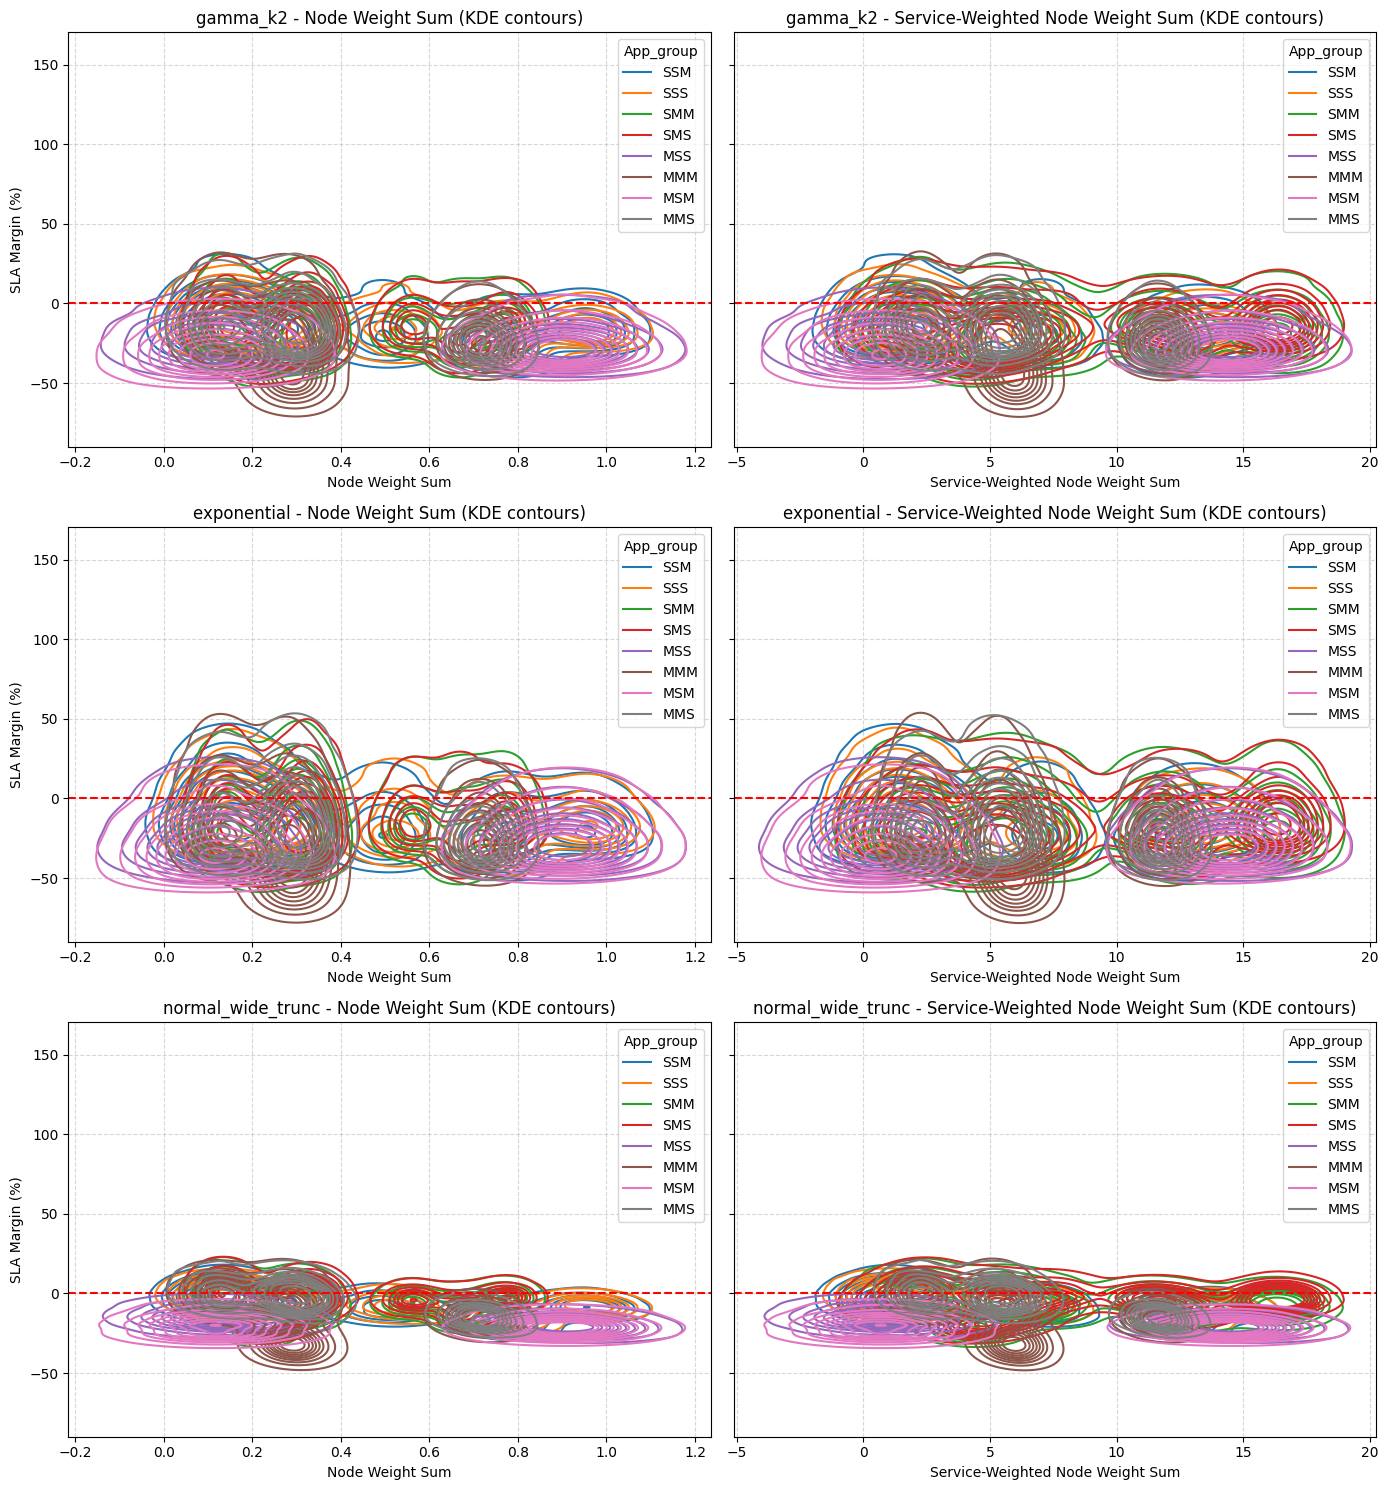

In [10]:
fig, axes = plt.subplots(
    nrows=len(dists),
    ncols=2,
    figsize=(14, 5 * len(dists)),
    sharey=True
)

if len(dists) == 1:
    axes = [axes]

for i, dist_to_plot in enumerate(dists):
    plot_df = scatter_df[scatter_df["Distribution"] == dist_to_plot].copy()

    ax_left = axes[i][0]
    ax_right = axes[i][1]

    sns.kdeplot(
        data=plot_df,
        x="Node_Weight_Sum",
        y="SLA_Margin_Perc",
        hue="App_group",
        fill=False,
        common_norm=False,
        ax=ax_left
    )

    sns.kdeplot(
        data=plot_df,
        x="Service_Weighted_Node_Weight_Sum",
        y="SLA_Margin_Perc",
        hue="App_group",
        fill=False,
        common_norm=False,
        ax=ax_right
    )

    ax_left.axhline(0, linestyle="--", color="red")
    ax_left.set_title(f"{dist_to_plot} - Node Weight Sum (KDE contours)")
    ax_left.set_xlabel("Node Weight Sum")
    ax_left.set_ylabel("SLA Margin (%)")
    ax_left.grid(True, linestyle="--", alpha=0.5)

    ax_right.axhline(0, linestyle="--", color="red")
    ax_right.set_title(f"{dist_to_plot} - Service-Weighted Node Weight Sum (KDE contours)")
    ax_right.set_xlabel("Service-Weighted Node Weight Sum")
    ax_right.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

* **`Scenario`**: identificativo dello scenario considerato, cioè della specifica configurazione di rete e di placement analizzata.

* **`App_ms`**: identificativo completo dell’applicazione o catena di microservizi considerata.

* **`App_group`**: versione aggregata di `App_ms` che ignora il prefisso numerico iniziale e mantiene solo la struttura dell’applicazione.

* **`Mean_CPU_Stress`**: media del rapporto tra la CPU richiesta da ciascun servizio e la CPU disponibile del nodo che lo ospita.  
  Se `q_u` è la domanda di CPU del servizio `u`, `Q_i` è la CPU disponibile del nodo `i` e `host(u)` indica il nodo che ospita `u`, allora questa metrica è definita come:

  $$
  \text{Mean\_CPU\_Stress} = \frac{1}{N}\sum_{u=1}^{N}\frac{q_u}{Q_{host(u)}}
  $$

  dove `N` è il numero di servizi deployati. Misura quindi quanto, in media, i servizi risultino “tirati” rispetto alla capacità dei nodi.

* **`Max_CPU_Stress`**: massimo rapporto tra la CPU richiesta da un servizio e la CPU disponibile del nodo che lo ospita.  
  Nella forma:

  $$
  \text{Max\_CPU\_Stress} = \max_{u}\left(\frac{q_u}{Q_{host(u)}}\right)
  $$

  evidenzia il caso più critico, cioè il servizio che grava maggiormente sul nodo a cui è assegnato.

* **`Aggregate_CPU_Stress`**: rapporto tra la somma delle CPU richieste dai servizi deployati e la somma delle CPU dei nodi effettivamente utilizzati.  
  Se `U` è l’insieme dei nodi effettivamente usati dal deployment, allora questa metrica è definita come:

  $$
  \text{Aggregate\_CPU\_Stress} = \frac{\sum_{u} q_u}{\sum_{i \in U} Q_i}
  $$

  e fornisce una misura complessiva del livello di stress delle risorse CPU per l’applicazione.

* **`Num_Services`**: numero totale di servizi dell’applicazione che risultano effettivamente assegnati a un nodo.

* **`Used_Nodes_Count`**: numero di nodi distinti utilizzati per ospitare i servizi dell’applicazione.

In [15]:
stress_df = build_resource_stress_dataset()
stress_df.head()

,Scenario,App_ms,App_group,Mean_CPU_Stress,Max_CPU_Stress,Aggregate_CPU_Stress,Num_Services,Used_Nodes_Count
0,1_26_solution_v0,1SMM,SMM,0.423797,1.000000,0.445860,6,4
1,1_26_solution_v0,1SMS,SMS,0.376657,0.789474,0.402235,7,5
2,1_26_solution_v0,1SSM,SSM,0.547156,1.000000,0.572519,7,5
3,1_26_solution_v0,1SSS,SSS,0.495536,1.000000,0.516779,8,5
4,1_26_solution_v10,1MMM,MMM,0.487582,1.000000,0.481481,5,3


In [16]:
stress_scatter_df = df.merge(
    stress_df,
    on=["Scenario", "App_ms", "App_group"],
    how="left"
)
stress_scatter_df.head()

,Distribution,Scenario,App_ms,App_group,Run,User,Application,Total Delay,Delay SLAs,SLA_Violation,SLA_Margin,SLA_Margin_Perc,Violation_Amount,Processing Delay,Propagation Delay,Mean_CPU_Stress,Max_CPU_Stress,Aggregate_CPU_Stress,Num_Services,Used_Nodes_Count
0,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_392,1,1,58,63.924,False,-5.924,-9.267,0.0,33,25,0.358256,0.857143,0.383481,10,6
1,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_619,2,2,49,63.924,False,-14.924,-23.346,0.0,23,26,0.358256,0.857143,0.383481,10,6
2,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_976,2,2,53,63.924,False,-10.924,-17.089,0.0,27,26,0.358256,0.857143,0.383481,10,6
3,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_338,1,1,56,63.924,False,-7.924,-12.396,0.0,31,25,0.358256,0.857143,0.383481,10,6
4,normal_wide_trunc,2_26_solution_v2,2SSM,SSM,run_235,1,1,55,63.924,False,-8.924,-13.960,0.0,30,25,0.358256,0.857143,0.383481,10,6


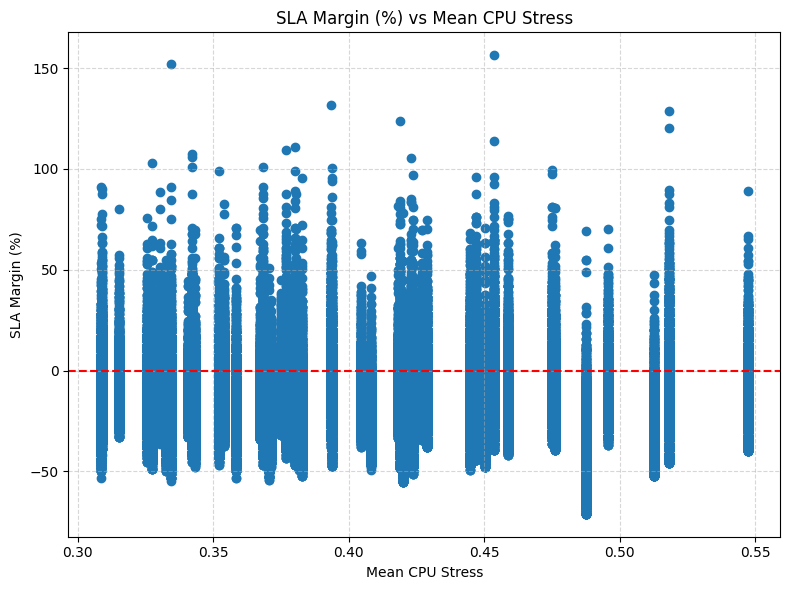

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(stress_scatter_df["Mean_CPU_Stress"], stress_scatter_df["SLA_Margin_Perc"])
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Mean CPU Stress")
plt.ylabel("SLA Margin (%)")
plt.title("SLA Margin (%) vs Mean CPU Stress")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

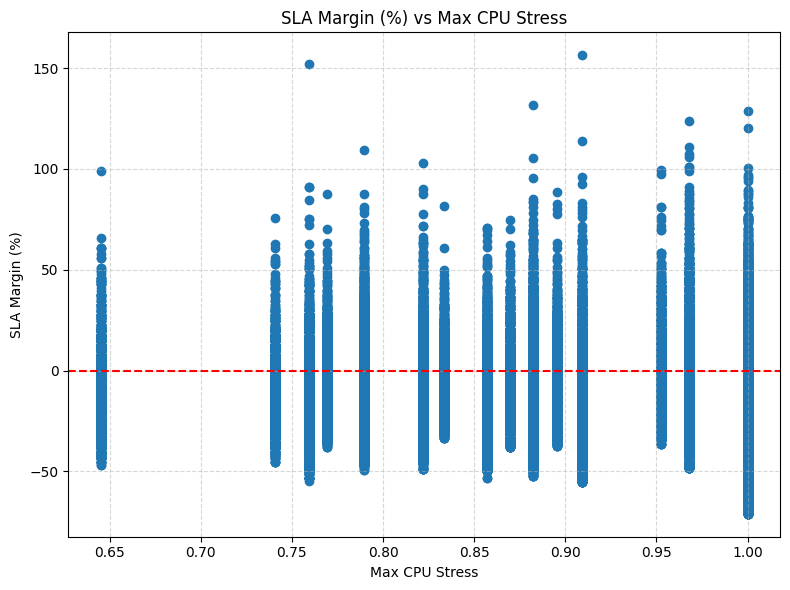

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(stress_scatter_df["Max_CPU_Stress"], stress_scatter_df["SLA_Margin_Perc"])
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Max CPU Stress")
plt.ylabel("SLA Margin (%)")
plt.title("SLA Margin (%) vs Max CPU Stress")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

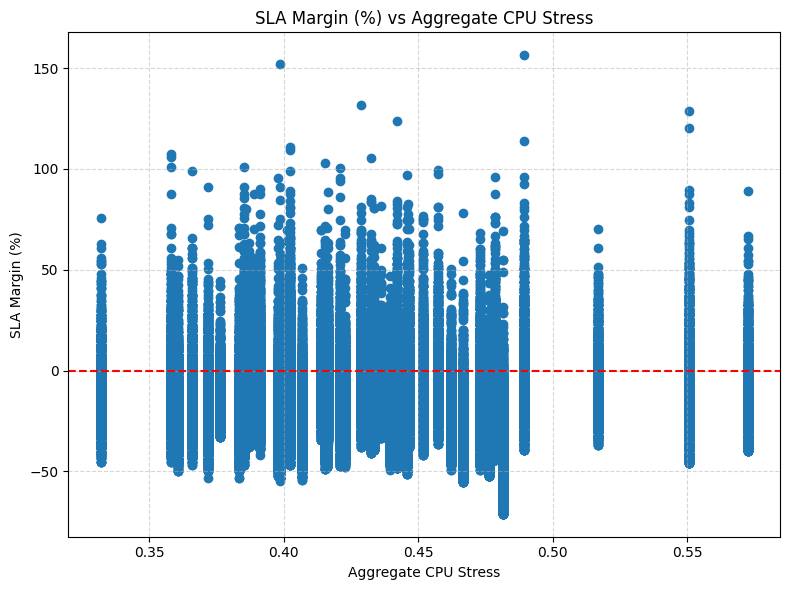

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(stress_scatter_df["Aggregate_CPU_Stress"], stress_scatter_df["SLA_Margin_Perc"])
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Aggregate CPU Stress")
plt.ylabel("SLA Margin (%)")
plt.title("SLA Margin (%) vs Aggregate CPU Stress")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [20]:
agg_stress_df = (
    stress_scatter_df.groupby(["Distribution", "App_group"])
    .agg(
        Mean_SLA_Margin_Perc=("SLA_Margin_Perc", "mean"),
        Median_SLA_Margin_Perc=("SLA_Margin_Perc", "median"),
        Violation_Rate=("SLA_Violation", "mean"),
        Mean_CPU_Stress=("Mean_CPU_Stress", "mean"),
        Max_CPU_Stress=("Max_CPU_Stress", "mean"),
        Aggregate_CPU_Stress=("Aggregate_CPU_Stress", "mean"),
    )
    .reset_index()
)

agg_stress_df["Violation_Rate"] = agg_stress_df["Violation_Rate"] * 100
agg_stress_df.head()

,Distribution,App_group,Mean_SLA_Margin_Perc,Median_SLA_Margin_Perc,Violation_Rate,Mean_CPU_Stress,Max_CPU_Stress,Aggregate_CPU_Stress
0,deterministic,MMM,-19.83200,-16.4990,0.0,0.451622,0.939304,0.484173
1,deterministic,MMS,-11.12375,-8.0730,0.0,0.395448,0.909892,0.429632
2,deterministic,MSM,-26.70900,-26.7090,0.0,0.460385,0.928571,0.457875
3,deterministic,MSS,-23.23750,-23.2375,0.0,0.410706,0.928571,0.411426
4,deterministic,SMM,-12.65070,-11.2355,0.0,0.393910,0.905233,0.440414


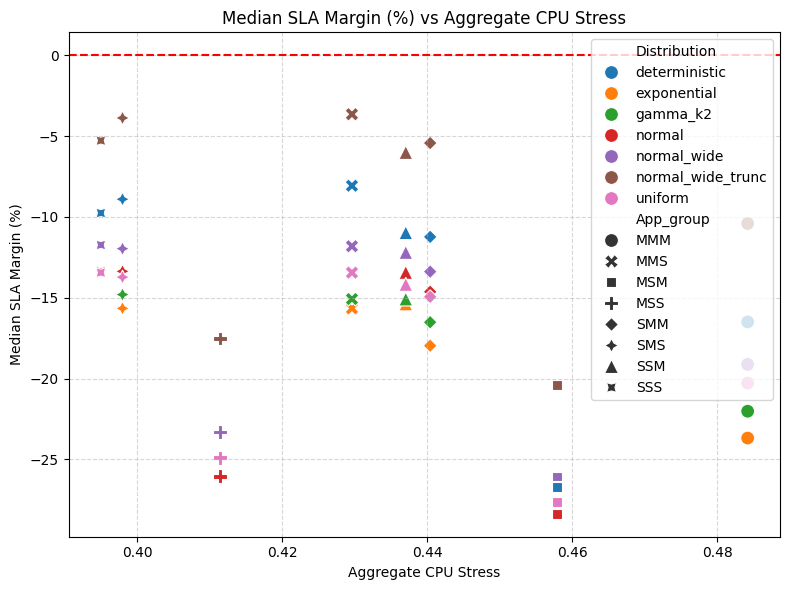

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=agg_stress_df,
    x="Aggregate_CPU_Stress",
    y="Median_SLA_Margin_Perc",
    hue="Distribution",
    style="App_group",
    s=100
)

plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Aggregate CPU Stress")
plt.ylabel("Median SLA Margin (%)")
plt.title("Median SLA Margin (%) vs Aggregate CPU Stress")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()